## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset


In [2]:
import os

possible_files = [
    "Sleep_Health_and_Lifestyle_Dataset.csv",
    "Sleep_Health_and_Lifestyle_Dataset(3).csv"
]

file_path = None
for file in possible_files:
    if os.path.exists(file):
        file_path = file
        break

if file_path is None:
    file_path = "/mnt/data/Sleep_Health_and_Lifestyle_Dataset(3).csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully from:", file_path)
df.head()

Dataset loaded successfully from: Sleep_Health_and_Lifestyle_Dataset.csv


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 3. Dataset Overview

In [3]:
print("Dataset shape:", df.shape)
df.info()
df.describe(include="all")

Dataset shape: (374, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ 

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


# Task 1: Identify Data Quality Issues
## 1.1 Missing Values

In [4]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Sleep Disorder             219
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
dtype: int64

## 1.2 Duplicate Records

In [6]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
df.dtypes

Number of duplicate rows: 0


Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [7]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()
numerical_columns_original = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns_original)

Categorical columns: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']
Numerical columns: ['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']


## 1.4 Unique Values

In [8]:
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))



Gender:
Gender
Male      189
Female    185
Name: count, dtype: int64

Occupation:
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

BMI Category:
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

Blood Pressure:
Blood Pressure
130/85    99
140/95    65
125/80    65
120/80    45
115/75    32
135/90    27
140/90     4
125/82     4
132/87     3
128/85     3
126/83     2
115/78     2
139/91     2
142/92     2
119/77     2
135/88     2
129/84     2
128/84     2
131/86     2
117/76     2
130/86     2
118/75     2
121/79     1
122/80     1
118/76     1
Name: count, dtype: int64

Sleep Disorder:
Sleep Disorder
NaN            219
Sleep Apnea

The main data quality issues are:

- Missing values in the `Sleep Disorder` column.
- `Blood Pressure` is stored as a combined text value instead of two numerical features.
- Categorical features need encoding if used 
- Possible outliers may exist in numerical features and should be checked using IQR.

# Task 2: Apply One Missing Value Strategy

In [9]:
df_clean = df.copy()

df_clean["Sleep Disorder"] = df_clean["Sleep Disorder"].fillna("None")

print("Missing values after handling Sleep Disorder:")
df_clean.isnull().sum()

Missing values after handling Sleep Disorder:


Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

In [10]:
df_clean["Sleep Disorder"].value_counts()

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

# Convert Blood Pressure into Numerical Features


In [11]:
bp_split = df_clean["Blood Pressure"].str.split("/", expand=True)
df_clean["Systolic BP"] = bp_split[0].astype(int)
df_clean["Diastolic BP"] = bp_split[1].astype(int)

df_clean[["Blood Pressure", "Systolic BP", "Diastolic BP"]].head()

,Blood Pressure,Systolic BP,Diastolic BP
0,126/83,126,83
1,125/80,125,80
2,125/80,125,80
3,140/90,140,90
4,140/90,140,90


# Task 3: Detect and Handle Outliers Using IQR


In [12]:
numeric_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic BP",
    "Diastolic BP"
]

df_clean[numeric_cols].head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP
0,27,6.1,6,42,6,77,4200,126,83
1,28,6.2,6,60,8,75,10000,125,80
2,28,6.2,6,60,8,75,10000,125,80
3,28,5.9,4,30,8,85,3000,140,90
4,28,5.9,4,30,8,85,3000,140,90


#  Detect Outliers

In [13]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,35.25,50.0,14.75,13.125,72.125,0
1,Sleep Duration,6.40,7.8,1.40,4.300,9.900,0
2,Quality of Sleep,6.00,8.0,2.00,3.000,11.000,0
3,Physical Activity Level,45.00,75.0,30.00,0.000,120.000,0
4,Stress Level,4.00,7.0,3.00,-0.500,11.500,0
5,Heart Rate,68.00,72.0,4.00,62.000,78.000,15
6,Daily Steps,5600.00,8000.0,2400.00,2000.000,11600.000,0
7,Systolic BP,125.00,135.0,10.00,110.000,150.000,0
8,Diastolic BP,80.00,90.0,10.00,65.000,105.000,0


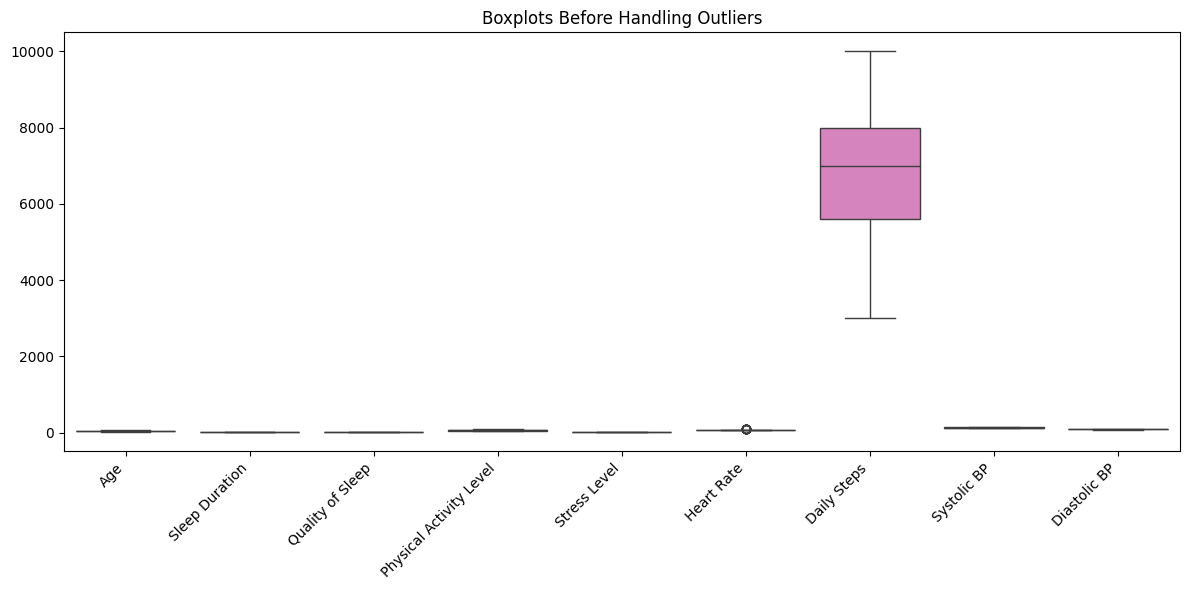

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[numeric_cols])
plt.xticks(rotation=45, ha="right")
plt.title("Boxplots Before Handling Outliers")
plt.tight_layout()
plt.show()

# Handle Outliers

In [15]:
df_capped = df_clean.copy()

for col in numeric_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

print("Outliers handled using capping.")
df_capped[numeric_cols].head()

Outliers handled using capping.


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP
0,27.0,6.1,6.0,42.0,6.0,77.0,4200.0,126.0,83.0
1,28.0,6.2,6.0,60.0,8.0,75.0,10000.0,125.0,80.0
2,28.0,6.2,6.0,60.0,8.0,75.0,10000.0,125.0,80.0
3,28.0,5.9,4.0,30.0,8.0,78.0,3000.0,140.0,90.0
4,28.0,5.9,4.0,30.0,8.0,78.0,3000.0,140.0,90.0


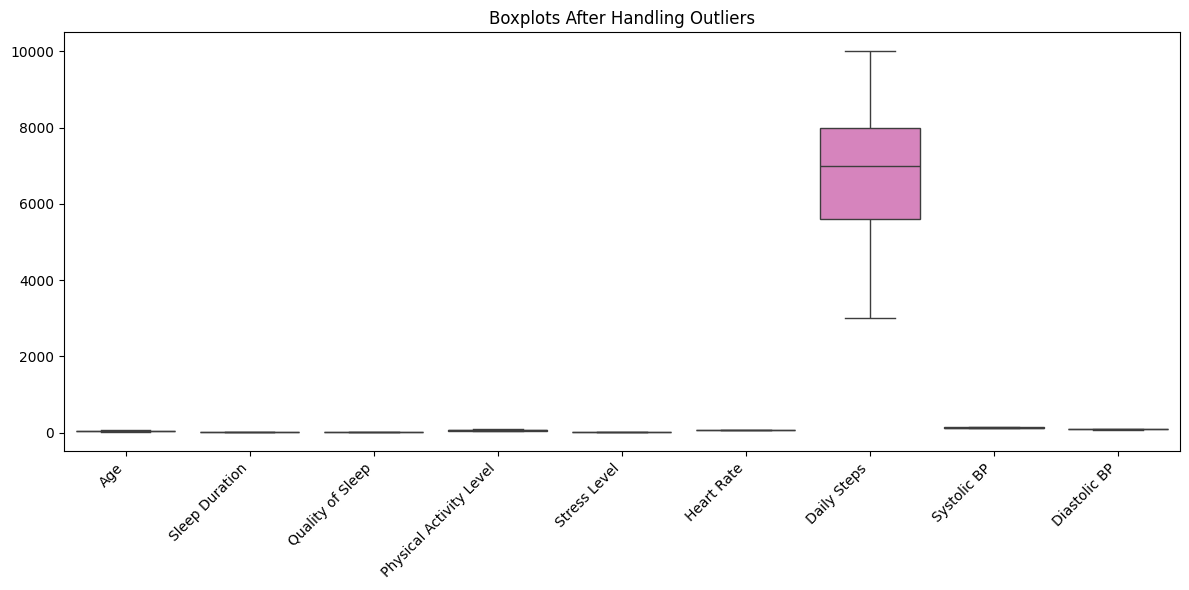

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_capped[numeric_cols])
plt.xticks(rotation=45, ha="right")
plt.title("Boxplots After Handling Outliers")
plt.tight_layout()
plt.show()

# Task 4: Normalize Numerical Features


In [17]:
zscore_scaler = StandardScaler()
zscore_scaled = zscore_scaler.fit_transform(df_capped[numeric_cols])

zscore_df = pd.DataFrame(zscore_scaled, columns=numeric_cols)
zscore_df.head()
zscore_summary = pd.DataFrame({
    "Mean": zscore_df.mean(),
    "Standard Deviation": zscore_df.std()
})
zscore_summary

,Mean,Standard Deviation
Age,-4.559633e-16,1.00134
Sleep Duration,1.348891e-15,1.00134
Quality of Sleep,2.469801e-16,1.00134
Physical Activity Level,-3.324732e-17,1.00134
Stress Level,1.994839e-16,1.00134
Heart Rate,-8.929280e-16,1.00134
Daily Steps,-9.499234e-17,1.00134
Systolic BP,-9.119265e-16,1.00134
Diastolic BP,-8.359326e-16,1.00134


# Task 5: Apply PCA and Interpret Explained Variance


In [18]:
pca = PCA()
pca_data = pca.fit_transform(zscore_df)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_results = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Explained Variance (%)": explained_variance * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})

pca_results

,Principal Component,Explained Variance Ratio,Explained Variance (%),Cumulative Variance (%)
0,PC1,0.398986,39.898586,39.898586
1,PC2,0.310343,31.034320,70.932906
2,PC3,0.172485,17.248543,88.181449
3,PC4,0.055411,5.541124,93.722573
4,PC5,0.032089,3.208925,96.931498
5,PC6,0.014591,1.459079,98.390577
6,PC7,0.008378,0.837794,99.228370
7,PC8,0.006300,0.629999,99.858370
8,PC9,0.001416,0.141630,100.000000


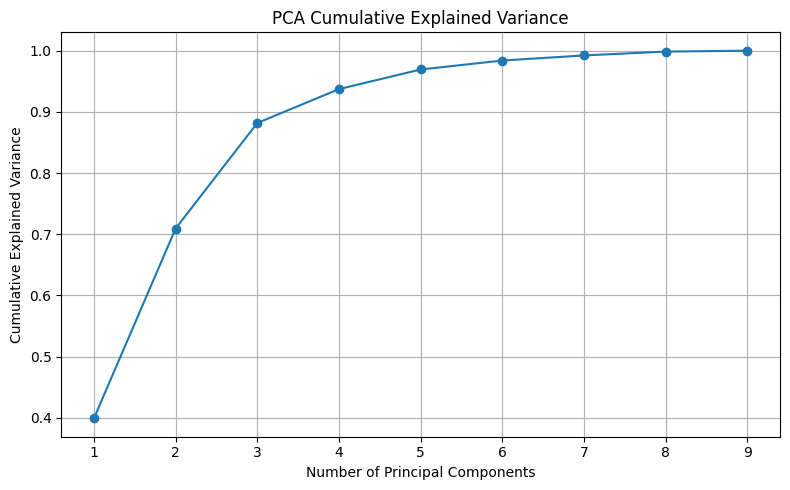

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print("Number of components needed to explain at least 90% of variance:", components_90)
print("Cumulative variance explained:", round(cumulative_variance[components_90 - 1] * 100, 2), "%")

Number of components needed to explain at least 90% of variance: 4
Cumulative variance explained: 93.72 %
